In [1]:
from resources.imports import *

In [2]:
from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MODEL, Autoencoder

In [3]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="MLP", format=1)
DAT.train_in.shape, DAT.val_in.shape, DAT.test_in.shape

((353, 900), (63, 900), (74, 900))

# Principal Component Analysis (PCA)

In [4]:
X_data = np.concatenate((DAT.train_in, DAT.val_in, DAT.test_in))
X_data = X_data[:500]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

X_data.shape

(490, 900)

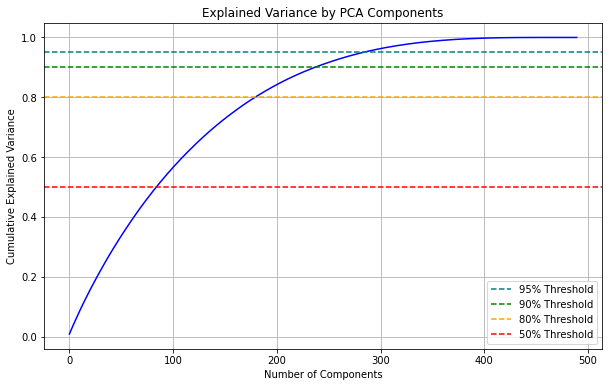

Number of components to capture 50% variance: 85
Number of components to capture 80% variance: 180
Number of components to capture 90% variance: 238
Number of components to capture 95% variance: 284
Number of components to capture 100% variance: 450


In [8]:
pca = PCA_()
pca.fit(data=X_scaled, scale=False, verbose=True)

In [11]:
X_reduced = pca.reduce(data=X_scaled, scale=False, verbose=True)

Original data shape: (490, 900)
Reduced data shape: (490, 450)


In [46]:
X_recon = pca.reconstruct()
X_recon = scaler.inverse_transform(X_recon)

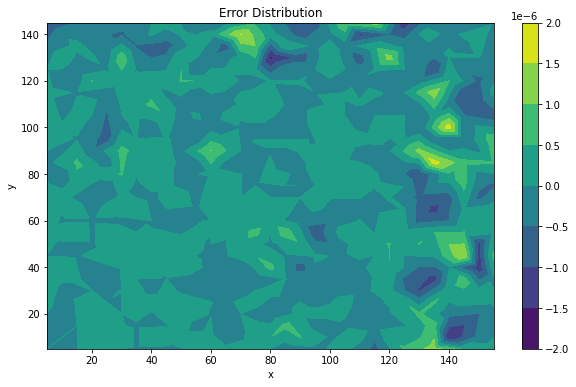

4.1999608019069467e-07

In [47]:
indx = 203
xy = 0

plt_outputs = X_recon[indx].reshape(X_recon.shape[1]//2, 2)[:,xy]
truth = DAT.train_in[indx].reshape(X_recon.shape[1]//2,2)[:,xy]

plot_Distribution(DAT.train_in1, plt_outputs, truth=truth)

np.sqrt(np.mean((plt_outputs - truth) ** 2))

# Autoencoder

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_size = DAT.train_in.shape[-1]
h_size = []
latent_size = 50

BATCH_SIZE = 1
LEARNING_RATE = 1e-3

Using device: cpu


In [60]:
trainDS = Dataset_(X_scaled[:100], X_scaled[:100])
testDS = Dataset_(X_scaled[-50:], X_scaled[-50:])

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [61]:
ENC = MODEL(
    typ="MLP",
    model=Autoencoder(in_size, latent_size, h_size, block="mlp").to(device), 
    lossf=nn.MSELoss(),
    opt=("adam", 0),
    batch=BATCH_SIZE,
    lr=LEARNING_RATE,
    data=DAT,
    train_dataloader=train_dataloader, 
    val_dataloader=None, 
    test_dataloader=test_dataloader,
    scheduler=("min", 0.7, 10, 1e-4, True), 
    earlyStop=EarlyStopping(patience=100, min_delta=1e-4, verbose=True),
    w_init=weights_init,
)

summary(ENC.model, input_size=(BATCH_SIZE, in_size))

Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [1, 1422]                 --
├─MLP: 1-1                               [1, 50]                   --
│    └─Linear: 2-1                       [1, 50]                   71,150
├─MLP: 1-2                               [1, 1422]                 --
│    └─Linear: 2-2                       [1, 1422]                 72,522
Total params: 143,672
Trainable params: 143,672
Non-trainable params: 0
Total mult-adds (M): 0.14
Input size (MB): 0.01
Forward/backward pass size (MB): 0.01
Params size (MB): 0.57
Estimated Total Size (MB): 0.59

Epoch: 1 - Loss: 1.8043566942214966
Epoch: 50 - Loss: 0.5809268355369568
Epoch: 100 - Loss: 0.4424422085285187
Epoch: 150 - Loss: 0.3688308894634247
Epoch: 200 - Loss: 0.3076392710208893
Epoch: 250 - Loss: 0.34281280636787415
Epoch: 300 - Loss: 0.402781218290329
Epoch: 350 - Loss: 0.35234296321868896
Epoch: 400 - Loss: 0.35932213068008423
Epoch: 450 - Loss: 0.33285531401634216
Early stopping triggered after 100 epochs without improvement.
Best Epoch: 442, with loss 0.3339996039867401


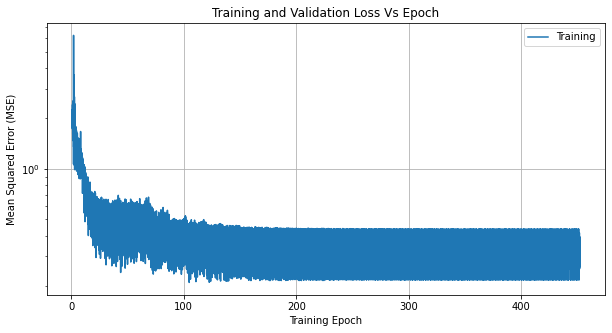

In [62]:
ENC.train(n_epochs=500, verbose=50, plot=True)

Best prediction: 301, Worst prediction: 329


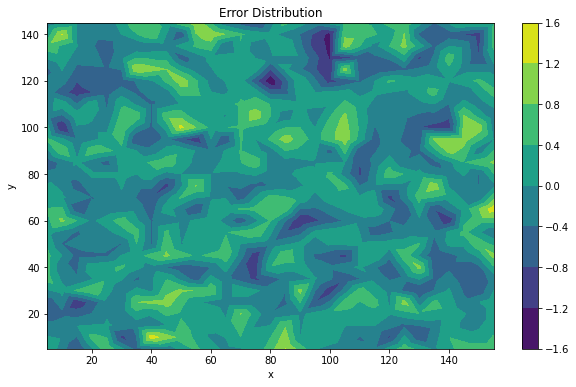

0.5356758

In [14]:
ENC.predict(stand=False, plot=False, test_dataloader=ENC.train_dataloader)

indx = 51      # ADAPT CLASS (model or data) TO AUTOENCODER STRUCTURES
xy = 0

plt_outputs = ENC.test_outputs[indx].reshape(X_recon.shape[1]//2, 2)[:,xy]
truth = ENC.truth[indx].reshape(X_recon.shape[1]//2,2)[:,xy]

plot_Distribution(ENC.data.train_in1, plt_outputs, truth=truth, typ="contour")

np.sqrt(np.mean(np.square(plt_outputs - truth)))

In [52]:
def objective(trial):
    # lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    # batch_size = trial.suggest_categorical('batch_size', [1, 2, 4])
    latent_size = trial.suggest_int('latent_size', 50, 500, step=10)

    model_instance = MODEL(
        typ="MLP",
        model=Autoencoder(in_size, latent_size, h_size, block="mlp").to(device),
        lossf=nn.MSELoss(),
        opt=("adam", 0),
        batch=BATCH_SIZE,
        lr=LEARNING_RATE,
        data=DAT,
        train_dataloader=train_dataloader,
        val_dataloader=None,
        scheduler=("min", 0.7, 10, 1e-4, True),
        earlyStop=EarlyStopping(patience=10, verbose=False),
        w_init=weights_init,
        optTrial=trial  # Pass the trial object here
    )

    model_instance.train(n_epochs=1000, verbose=50)
    return model_instance.best_loss

study = hOpt(objective, n_trials=20, prnt=True, save=False, path="models/", name="Autoencoder-DimReduction")

[I 2025-06-20 10:56:42,072] A new study created in memory with name: no-name-e5f39627-7b7a-428f-8f2f-9abb44703ab9


Epoch: 1 - Loss: 1.7350435256958008
Epoch: 50 - Loss: 0.42047566175460815


[I 2025-06-20 10:57:15,331] Trial 0 finished with value: 0.37034550309181213 and parameters: {'latent_size': 470}. Best is trial 0 with value: 0.37034550309181213.


Best Epoch: 72, with loss 0.37034550309181213
Epoch: 1 - Loss: 1.9050889015197754
Epoch: 50 - Loss: 0.3338008522987366


[I 2025-06-20 10:57:34,178] Trial 1 finished with value: 0.3063221275806427 and parameters: {'latent_size': 370}. Best is trial 1 with value: 0.3063221275806427.


...

Epoch: 1 - Loss: 1.9267117977142334


[I 2025-06-20 10:58:48,231] Trial 17 pruned. 
[I 2025-06-20 10:58:48,518] Trial 18 pruned. 


Epoch: 1 - Loss: 1.9991337060928345


[I 2025-06-20 10:58:49,015] Trial 19 pruned. 



 Optimization Finished. Study statistics: 
  Number of finished trials: 20

Best trial 
 Loss: 0.2698553800582886

 Hyperparameters:
  latent_size: 330


In [16]:
load_bestParams(path="models/", name="Autoencoder-DimReduction")

{'latent_size': 280}